# regression 
for only the order finding data!

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.constants import R
from scipy import stats

In [28]:
df = pd.read_csv("orderdat.tsv", sep='\t')
df['Temperature'] += 273.
df

,Temperature,[HCl],[Iodine],[Acetone],[Water],Rate
0,302.563009,0.024107,0.002129,1.990460,44.873879,4.703519e-06
1,302.407199,0.011339,0.002293,1.980991,45.530455,2.169842e-06
2,302.364833,0.040817,0.001998,1.967061,44.114360,7.572028e-06
3,302.266572,0.020536,0.004176,1.953436,44.086957,3.571443e-06
4,302.561582,0.020939,0.001026,1.991848,45.656391,4.460606e-06
5,302.265952,0.020088,0.003012,0.465670,50.831232,7.334901e-07
6,302.738055,0.020694,0.002148,4.034431,36.708748,8.205428e-06


# multiple linear regression

do not consider temperature in multiple linear

In [29]:
X = df[['[HCl]', '[Iodine]', '[Acetone]']].to_numpy()
y = df['Rate'].to_numpy()

X = np.log(X)
X = np.hstack([np.ones((X.shape[0], 1)), X])
y = np.log(y)

In [30]:
coeffs, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)

# Standard errors of fitted parameters (b0-b3)
n, p = X.shape
rss = residuals[0] if residuals.size > 0 else np.sum((y - X @ coeffs) ** 2)
dof = n - p
mse = rss / dof

cov_coeffs = mse * np.linalg.inv(X.T @ X)
se_b0, se_b1, se_b2, se_b3 = np.sqrt(np.diag(cov_coeffs))

b0, b1, b2, b3 = coeffs

# 95% confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level
t_value = stats.t.ppf(1 - alpha/2, len(y) - len(coeffs))

print("multiple linear regression results !!: (95 % CI)")
print(f"  ln(k) = {b0:.2f} ± {t_value*se_b0:.2f}")
print(f"  alpha (HCl) = {b1:.4f} ± {1*se_b1:.4f}")
print(f"  beta (Acetone) = {b3:.4f} ± {1*se_b3:.4f}")
print(f"  gamma (Iodine) = {b2:.4f} ± {1*se_b2:.4f}")

print(f'\nt(95%, {len(y) - len(coeffs)} DOF) = {t_value:.2f}')

y_pred_lr = X @ coeffs
ss_res_lr = np.sum((y - y_pred_lr) ** 2)
ss_tot_lr = np.sum((y - np.mean(y)) ** 2)
r2_lr = 1 - ss_res_lr / ss_tot_lr
print(f"\nR² = {r2_lr:.6f}")

multiple linear regression results !!: (95 % CI)
  ln(k) = -10.27 ± 0.80
  alpha (HCl) = 0.9727 ± 0.0356
  beta (Acetone) = 1.0925 ± 0.0213
  gamma (Iodine) = -0.1371 ± 0.0324

t(95%, 3 DOF) = 3.18

R² = 0.999240


# nonlinear regression

In [31]:
X = df[['Temperature', '[HCl]', '[Iodine]', '[Acetone]']].to_numpy()
y = df['Rate'].to_numpy()
X

array([[3.02563009e+02, 2.41072367e-02, 2.12883074e-03, 1.99046006e+00],
       [3.02407199e+02, 1.13387808e-02, 2.29271085e-03, 1.98099062e+00],
       [3.02364833e+02, 4.08170078e-02, 1.99791740e-03, 1.96706077e+00],
       [3.02266572e+02, 2.05358576e-02, 4.17557370e-03, 1.95343571e+00],
       [3.02561582e+02, 2.09393908e-02, 1.02598351e-03, 1.99184841e+00],
       [3.02265952e+02, 2.00876516e-02, 3.01237928e-03, 4.65669790e-01],
       [3.02738055e+02, 2.06935563e-02, 2.14764728e-03, 4.03443122e+00]])

In [32]:
def rate_equation(x, k, alpha, beta, gamma):
    x = np.asarray(x)
    C_HCl = x[:, 1]
    C_I = x[:, 2]
    C_A = x[:, 3]
    return np.exp(k) * (C_A**alpha) * (C_HCl**beta) * (C_I**gamma)

popt, pcov = curve_fit(rate_equation, X, y, p0=[-10, 1, 1, 0])

In [33]:
perr = np.sqrt(np.diag(pcov))
param_names = ['k', 'alpha', 'beta', 'gamma']

for name, val, err in zip(param_names, popt, perr):
    print(f"{name} = {val:.8f} ± {err:.8f}")

k = -10.26509117 ± 0.15186447
alpha = 1.02636727 ± 0.01969024
beta = 0.95375707 ± 0.02122101
gamma = -0.13411015 ± 0.02117502


In [34]:
df = pd.DataFrame({'name':param_names,'value':popt, 'error':perr})
df.to_clipboard(excel=True)

In [35]:
y_pred = rate_equation(X, *popt)
y_true = y

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

r_squared = 1 - ss_res / ss_tot
print(f"R squared = {r_squared:.6f}")

R squared = 0.999506


In [36]:
from scipy import stats

# Calculate 95% confidence intervals for each parameter
confidence_level = 0.95
alpha = 1 - confidence_level
t_value = stats.t.ppf(1 - alpha/2, len(y_true) - len(popt))
print(t_value)

print("95% Confidence Intervals:")
print("-" * 50)
for name, val, err in zip(param_names, popt, perr):
    ci_lower = val - t_value * err
    ci_upper = val + t_value * err
    print(f"{name}: [{(ci_lower):.6f}, {(ci_upper):.6f}]")

print("95% Confidence Intervals:")
print("-" * 50)
for name, val, err in zip(param_names, popt, perr):
    print(f"{name}: {val:.3f} ± {t_value*err:.3f}")

print("\nCI on k:")
print("-" * 10)
for name, val, err in zip(param_names, popt, perr):
    if name == 'k':
        ci_lower = np.log(val - t_value * err)
        ci_upper = np.log(val + t_value * err)
        val = np.log(val)
        plus = ci_upper - val
        minus = val - ci_lower
        print(f"ln({name}): {val:.2f} +{plus:.2f} -{minus:.2f}")

3.182446305284263
95% Confidence Intervals:
--------------------------------------------------
k: [-10.748392, -9.781791]
alpha: [0.963704, 1.089030]
beta: [0.886222, 1.021292]
gamma: [-0.201499, -0.066722]
95% Confidence Intervals:
--------------------------------------------------
k: -10.265 ± 0.483
alpha: 1.026 ± 0.063
beta: 0.954 ± 0.068
gamma: -0.134 ± 0.067

CI on k:
----------
ln(k): nan +nan -nan


/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_64449/262352936.py:25: RuntimeWarning: invalid value encountered in log
  ci_lower = np.log(val - t_value * err)
/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_64449/262352936.py:26: RuntimeWarning: invalid value encountered in log
  ci_upper = np.log(val + t_value * err)
/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_64449/262352936.py:27: RuntimeWarning: invalid value encountered in log
  val = np.log(val)


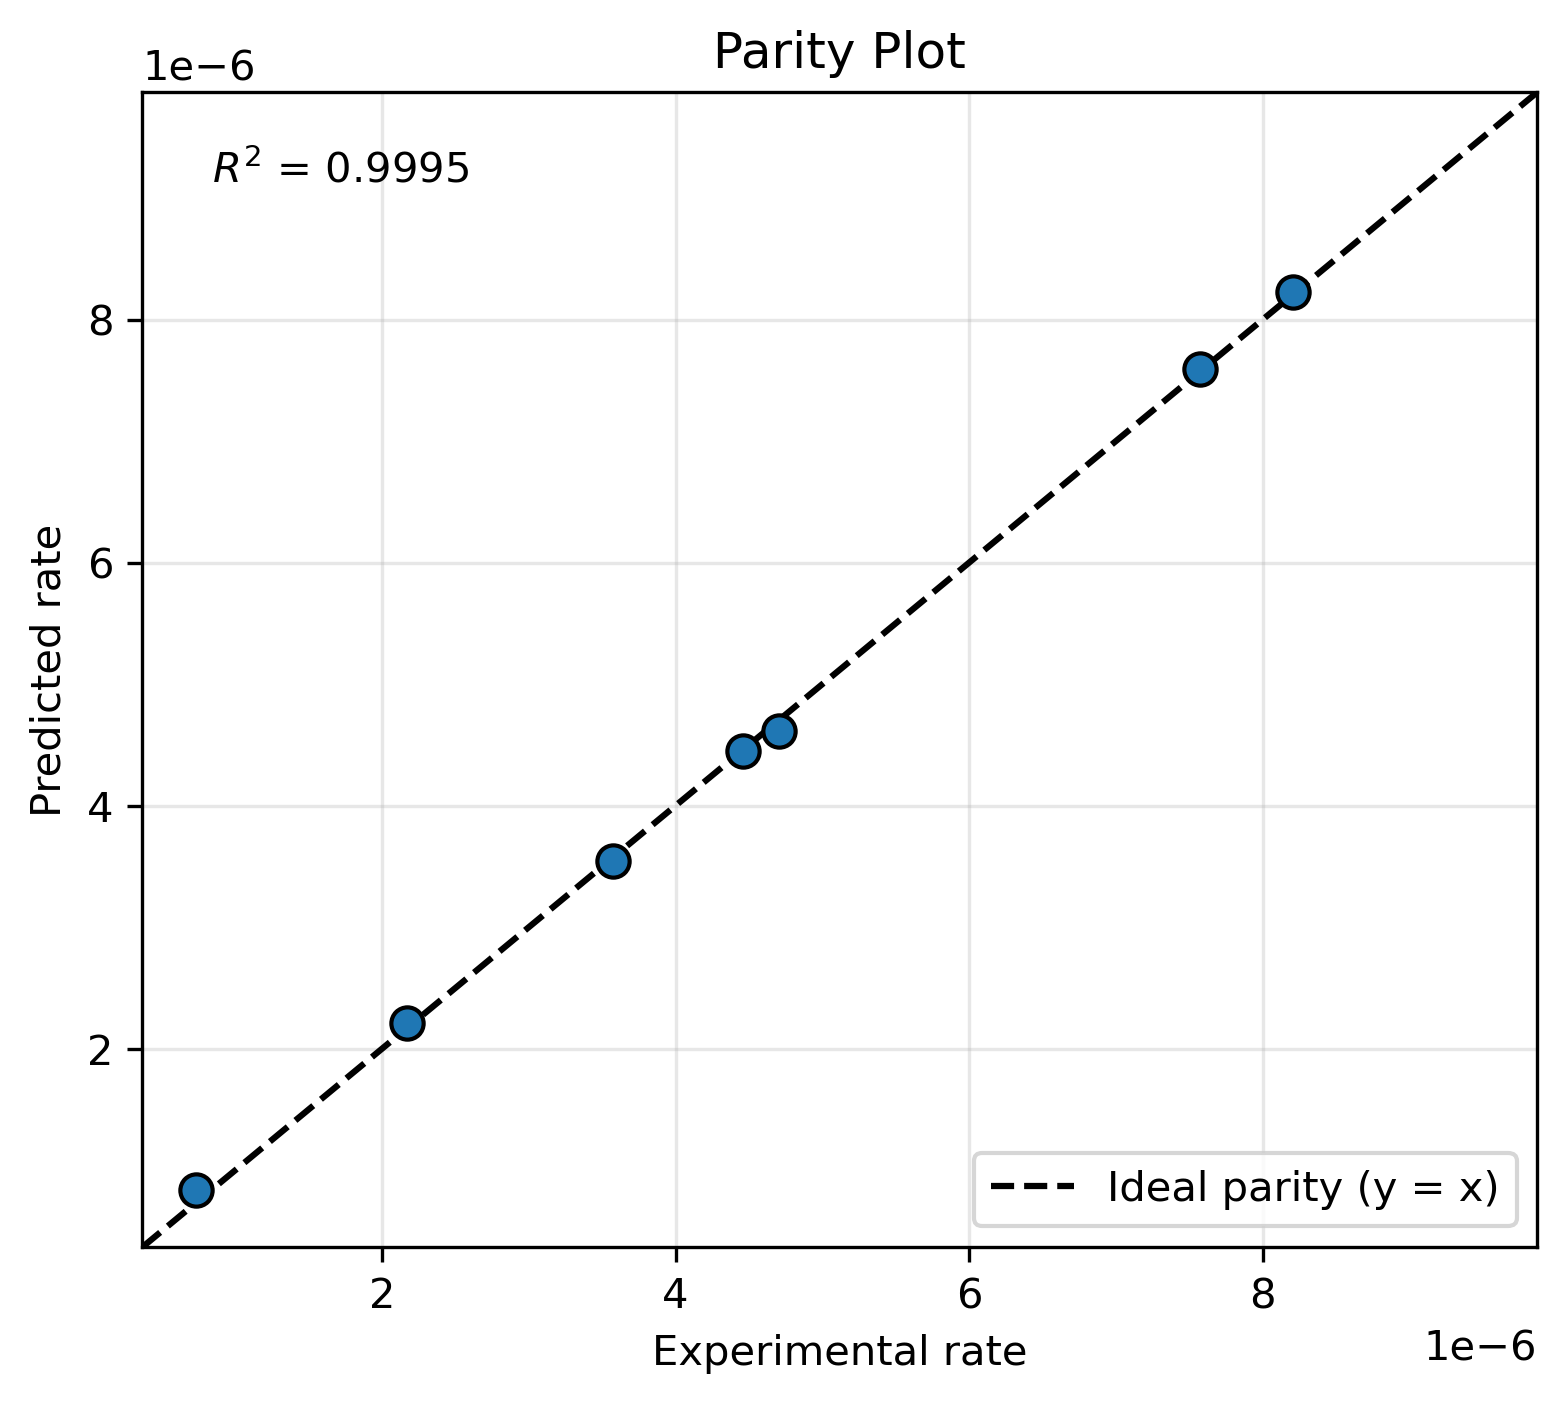

In [37]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

ax.scatter(y_true, y_pred, s=60, alpha=1.0, edgecolor='black', zorder=100)

lims = [
    min(y_true.min()*0.5, y_pred.min()*0.5),
    max(y_true.max()*1.2, y_pred.max()*1.2)
]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal parity (y = x)')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Experimental rate')
ax.set_ylabel('Predicted rate')
ax.set_title('Parity Plot')
ax.text(0.05, 0.95, f'$R^2$ = {r_squared:.4f}', transform=ax.transAxes, va='top')
ax.grid(True, alpha=0.3)
ax.legend()
